In [1]:
import numpy as np
import pandas as pd

def simulate_clayton_copula(n, theta, rng):
    u1 = rng.uniform(size=n)
    w = rng.uniform(size=n)
    u2 = (u1**(-theta) * (w**(-theta/(1+theta)) - 1) + 1) ** (-1/theta)
    return u1, u2

def detection_delay(u1, u2, m0, c, rho, r):
    n = len(u1)
    stat = np.zeros(n)
    for t in range(1, n):
        innovation = abs(u1[t] - u2[t])
        stat[t] = rho * stat[t-1] + (1 - rho) * innovation
    limit = c * stat[:m0].std()
    threshold = r * limit + (1 - r) * stat[:m0].mean()
    post = stat[m0:]
    triggered = np.where(post > threshold)[0]
    return triggered[0] if len(triggered) > 0 else np.nan

def run_simulation_study(theta_pairs, r_values, m0=20, c=1.25, rho=0.5,
                          n_sims=100, path_length=120, seed=42):
    rng = np.random.default_rng(seed)
    rows = []
    for theta_a, theta_b in theta_pairs:
        for r in r_values:
            delays = []
            for _ in range(n_sims):
                u1, u2 = simulate_clayton_copula(path_length, theta_a, rng)
                d = detection_delay(u1, u2, m0, c, rho, r)
                if not np.isnan(d):
                    delays.append(d)
            delays = np.array(delays)
            rows.append({
                "theta_a": theta_a, "theta_b": theta_b, "r": r,
                "mean": delays.mean(), "std_dev": delays.std(ddof=1),
                "max": delays.max(), "min": delays.min()
            })
    return pd.DataFrame(rows)

theta_pairs = [(0.50, 0.10), (0.75, 0.10), (1.00, 0.10),
               (0.10, 0.50), (0.10, 0.75), (0.10, 1.00)]
r_values = [0.25, 0.50, 0.75]

results = run_simulation_study(theta_pairs, r_values, m0=20, c=1.25, rho=0.5, n_sims=100)
print(results.round(2))

    theta_a  theta_b     r  mean  std_dev  max  min
0      0.50     0.10  0.25  0.98     1.77   10    0
1      0.50     0.10  0.50  0.87     1.75    9    0
2      0.50     0.10  0.75  0.66     1.52    7    0
3      0.75     0.10  0.25  1.21     2.08   13    0
4      0.75     0.10  0.50  0.78     1.31    6    0
5      0.75     0.10  0.75  0.42     0.98    5    0
6      1.00     0.10  0.25  0.88     1.75   11    0
7      1.00     0.10  0.50  0.78     1.57   10    0
8      1.00     0.10  0.75  0.62     1.52    8    0
9      0.10     0.50  0.25  0.94     1.96   10    0
10     0.10     0.50  0.50  0.45     0.95    4    0
11     0.10     0.50  0.75  0.31     0.75    5    0
12     0.10     0.75  0.25  0.87     1.51    7    0
13     0.10     0.75  0.50  0.50     1.00    6    0
14     0.10     0.75  0.75  0.52     1.70   15    0
15     0.10     1.00  0.25  1.14     2.07    8    0
16     0.10     1.00  0.50  0.63     1.40    7    0
17     0.10     1.00  0.75  0.33     0.83    4    0


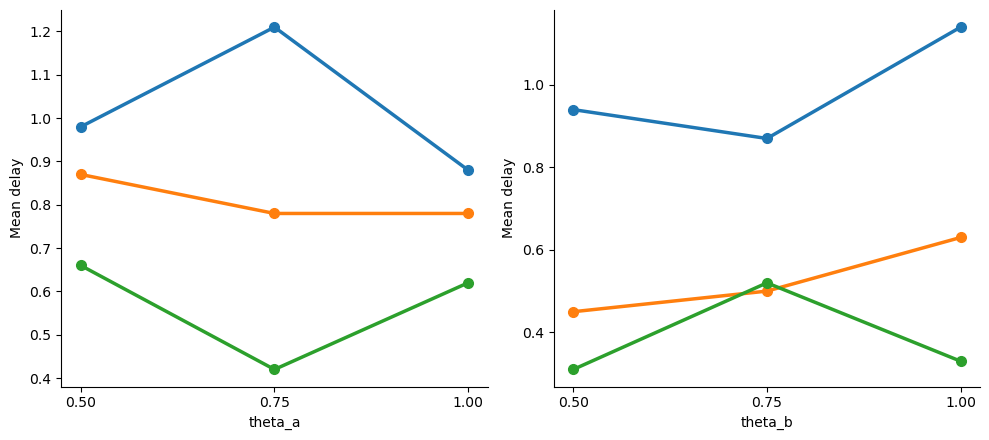

In [9]:
import matplotlib.pyplot as plt

theta_vals = sorted(left["theta_a"].unique())
colors_mpl = {0.25: "#1f77b4", 0.50: "#ff7f0e", 0.75: "#2ca02c"}

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

for r in [0.25, 0.50, 0.75]:
    d = left[left.r == r].sort_values("theta_a")
    axes[0].plot(d.theta_a, d["mean"], marker="o", color=colors_mpl[r],
                 linewidth=2.5, markersize=7)

for r in [0.25, 0.50, 0.75]:
    d = right[right.r == r].sort_values("theta_b")
    axes[1].plot(d.theta_b, d["mean"], marker="o", color=colors_mpl[r],
                 linewidth=2.5, markersize=7)

axes[0].set_xlabel("theta_a")
axes[0].set_ylabel("Mean delay")
axes[1].set_xlabel("theta_b")
axes[1].set_ylabel("Mean delay")

for ax in axes:
    ax.set_xticks(theta_vals)
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("detection_delay_figure49_mpl.png", dpi=200, transparent=True)
plt.show()
plt.close()

In [1]:
import numpy as np
from scipy.stats import kendalltau
from itertools import combinations
import matplotlib.pyplot as plt
import os

def theta_path(t, theta_a, theta_b):
    """Piecewise-linear theta_t exactly as specified on the slide."""
    if t <= 50:
        return theta_a
    elif t <= 150:
        return theta_a + (t - 50) / 100 * (theta_b - theta_a)
    else:
        return theta_b

def simulate_clayton_dvar(theta, d, rng):
    """Marshall-Olkin frailty method for d-dim Clayton copula draw."""
    v = rng.gamma(shape=1 / theta, scale=1.0)
    x = rng.exponential(scale=1.0, size=d)
    return (1 + x / v) ** (-1 / theta)

def simulate_path(t_grid, d, theta_a, theta_b, rng):
    n_obs = len(t_grid)
    U = np.zeros((n_obs, d))
    thetas = np.zeros(n_obs)
    for i, t in enumerate(t_grid):
        th = theta_path(t, theta_a, theta_b)
        thetas[i] = th
        U[i, :] = simulate_clayton_dvar(th, d, rng)
    return U, thetas

pairs_d = list(combinations(range(6), 2))

def pairwise_kendall_tau(U_window):
    taus = [kendalltau(U_window[:, i], U_window[:, j])[0] for i, j in pairs_d]
    taus = [t for t in taus if not np.isnan(t)]
    return np.mean(taus) if taus else np.nan

def clayton_theta_from_tau(tau):
    tau = np.clip(tau, -0.999, 0.999)
    return max(2 * tau / (1 - tau), 1e-4)

def rolling_theta_estimate(U, m0):
    n = U.shape[0]
    est = np.full(n, np.nan)
    for t in range(m0, n):
        tau = pairwise_kendall_tau(U[t - m0:t, :])
        est[t] = clayton_theta_from_tau(tau)
    return est

def run_experiment(theta_a, theta_b, d=6, m0=20, c=1.25, n_sims=100,
                    t_start=-350, t_end=350, seed=0):
    t_grid = np.arange(t_start, t_end + 1)
    n_obs = len(t_grid)
    rng = np.random.default_rng(seed)
    paths = np.full((n_sims, n_obs), np.nan)
    for s in range(n_sims):
        U, thetas = simulate_path(t_grid, d, theta_a, theta_b, rng)
        paths[s, :] = rolling_theta_estimate(U, m0)

    median = np.full(n_obs, np.nan)
    q25 = np.full(n_obs, np.nan)
    q75 = np.full(n_obs, np.nan)
    median[m0:] = np.median(paths[:, m0:], axis=0)
    q25[m0:] = np.percentile(paths[:, m0:], 25, axis=0)
    q75[m0:] = np.percentile(paths[:, m0:], 75, axis=0)
    return t_grid, median, q25, q75, thetas

theta_a, theta_b = 1.00, 0.10
t_grid, median_up, q25_up, q75_up, true_up = run_experiment(
    theta_a, theta_b, m0=20, c=1.25, n_sims=100, seed=1)
t_grid2, median_down, q25_down, q75_down, true_down = run_experiment(
    theta_b, theta_a, m0=20, c=1.25, n_sims=100, seed=2)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
mask = (t_grid >= 0) & (t_grid <= 350)

axes[0].plot(t_grid[mask], median_up[mask], color="black", linewidth=1.8)
axes[0].plot(t_grid[mask], q25_up[mask], color="gray", linestyle=":", linewidth=1)
axes[0].plot(t_grid[mask], q75_up[mask], color="gray", linestyle=":", linewidth=1)
axes[0].plot(t_grid[mask], true_up[mask], color="black", linestyle="--", linewidth=1.3)

axes[1].plot(t_grid[mask], median_down[mask], color="black", linewidth=1.8)
axes[1].plot(t_grid[mask], q25_down[mask], color="gray", linestyle=":", linewidth=1)
axes[1].plot(t_grid[mask], q75_down[mask], color="gray", linestyle=":", linewidth=1)
axes[1].plot(t_grid[mask], true_down[mask], color="black", linestyle="--", linewidth=1.3)

for ax in axes:
    ax.set_xlim(0, 350)
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("figure50_slide_experiment.png", dpi=200, transparent=True)
plt.close()